# Day 4: Fund Performance Analytics

This notebook computes key performance metrics for all 40 mutual fund schemes, including CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.
Finally, we build a **composite Fund Scorecard** based on weighted rankings and compare the top funds against benchmark indices.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Connect to database
conn = sqlite3.connect('../bluestock_mf.db')

# Load raw NAV data and Funds
df_nav = pd.read_sql_query("SELECT date, amfi_code, nav FROM fact_nav ORDER BY date", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

df_fund = pd.read_sql_query("SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund", conn)
fund_dict = dict(zip(df_fund['amfi_code'], df_fund['scheme_name']))

# Pivot NAV data
pivot_nav = df_nav.pivot(index='date', columns='amfi_code', values='nav').dropna(how='all')
# Forward fill missing values to have a continuous series before calculating returns
pivot_nav = pivot_nav.ffill()


## 1. Compute Daily Returns
`daily_return = nav_t / nav_t-1 - 1`

In [2]:
daily_returns = pivot_nav.pct_change().dropna(how='all')
# Validate distribution
display(daily_returns.describe().T.head())


,count,mean,std,min,25%,50%,75%,max
amfi_code,,,,,,,,
100016,1607.0,0.000101,0.007749,-0.024744,-0.003487,0.0,0.003502,0.032145
100025,1607.0,0.000122,0.002081,-0.008188,-0.000778,0.0,0.001079,0.008837
100033,1607.0,0.000772,0.010097,-0.044238,-0.003321,0.0,0.005645,0.041954
101206,1607.0,0.000609,0.007768,-0.038121,-0.002774,0.0,0.004420,0.033956
101207,1607.0,0.000303,0.013741,-0.051847,-0.006170,0.0,0.006855,0.054851


## 2. Compute CAGR (1yr, 3yr, 5yr)
`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`

In [3]:
metrics = []

max_date = pivot_nav.index.max()
for col in pivot_nav.columns:
    s = pivot_nav[col].dropna()
    if s.empty: continue
    
    end_val = s.iloc[-1]
    
    # Helper to calculate return over N years
    def get_cagr(years):
        start_date = max_date - pd.DateOffset(years=years)
        # Find closest date
        closest_dates = s[s.index <= start_date]
        if closest_dates.empty: return np.nan
        start_val = closest_dates.iloc[-1]
        return ((end_val / start_val) ** (1/years)) - 1
        
    metrics.append({
        'amfi_code': col,
        'CAGR_1yr': get_cagr(1),
        'CAGR_3yr': get_cagr(3),
        'CAGR_5yr': get_cagr(5)
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics.head())


,amfi_code,CAGR_1yr,CAGR_3yr,CAGR_5yr
0,100016,-0.022243,0.012926,NaN
1,100025,0.037050,0.039164,NaN
2,100033,0.532324,0.324425,NaN
3,101206,0.479241,0.289677,NaN
4,101207,-0.239860,-0.041524,NaN


## 3 & 4. Sharpe and Sortino Ratios
Rf = 6.5%. 
`Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)`

In [4]:
rf = 0.065
rf_daily = (1 + rf)**(1/252) - 1

sharpe_ratios = []
sortino_ratios = []

for col in daily_returns.columns:
    fund_ret = daily_returns[col].dropna()
    excess_ret = fund_ret - rf_daily
    
    # Sharpe
    std_dev = excess_ret.std()
    if std_dev > 0:
        sharpe = (excess_ret.mean() / std_dev) * np.sqrt(252)
    else:
        sharpe = np.nan
        
    # Sortino
    downside_ret = excess_ret[excess_ret < 0]
    downside_std = downside_ret.std()
    if downside_std > 0:
        sortino = (excess_ret.mean() / downside_std) * np.sqrt(252)
    else:
        sortino = np.nan
        
    sharpe_ratios.append({'amfi_code': col, 'Sharpe': sharpe})
    sortino_ratios.append({'amfi_code': col, 'Sortino': sortino})

df_metrics = df_metrics.merge(pd.DataFrame(sharpe_ratios), on='amfi_code')
df_metrics = df_metrics.merge(pd.DataFrame(sortino_ratios), on='amfi_code')


## 5. Alpha and Beta
OLS regression of fund returns on Nifty 100 returns.

In [5]:
# Load Benchmark (Nifty 100)
try:
    df_bench = pd.read_csv('../data/raw/benchmark_indices.csv')
    df_bench['date'] = pd.to_datetime(df_bench['date'])
    nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].set_index('date')['close_value'].sort_index()
    nifty100_ret = nifty100.pct_change().dropna()
except Exception as e:
    print(f"Warning: NIFTY100 data missing or failed to load. Using a proxy market return. {e}")
    # Proxy if missing
    nifty100_ret = daily_returns.mean(axis=1)

alpha_beta = []

for col in daily_returns.columns:
    # Align dates
    aligned = pd.concat([daily_returns[col], nifty100_ret], axis=1, join='inner').dropna()
    if len(aligned) > 50: # need enough data points
        fund_r = aligned.iloc[:, 0]
        mark_r = aligned.iloc[:, 1]
        slope, intercept, r_value, p_value, std_err = linregress(mark_r, fund_r)
        
        beta = slope
        alpha = intercept * 252 # Annualize alpha
    else:
        beta = np.nan
        alpha = np.nan
        
    alpha_beta.append({'amfi_code': col, 'Alpha': alpha, 'Beta': beta})

df_ab = pd.DataFrame(alpha_beta)
df_ab.to_csv('../data/processed/alpha_beta.csv', index=False)
df_metrics = df_metrics.merge(df_ab, on='amfi_code')
display(df_ab.head())


,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


## 6. Maximum Drawdown
`min(NAV / running_max - 1)`

In [6]:
max_drawdowns = []

for col in pivot_nav.columns:
    nav_series = pivot_nav[col].dropna()
    running_max = nav_series.cummax()
    drawdown = (nav_series / running_max) - 1
    max_dd = drawdown.min()
    
    # Find worst drawdown date
    if drawdown.empty:
        worst_date = None
    else:
        worst_date = drawdown.idxmin().strftime('%Y-%m-%d')
        
    max_drawdowns.append({
        'amfi_code': col, 
        'Max_Drawdown': max_dd,
        'Worst_DD_Date': worst_date
    })

df_metrics = df_metrics.merge(pd.DataFrame(max_drawdowns), on='amfi_code')


## 7. Composite Fund Scorecard (0-100)
30% x 3yr return rank + 25% x Sharpe rank + 20% x Alpha rank + 15% x Expense ratio rank (inverse) + 10% x Max DD rank (inverse)

In [7]:
df_score = df_metrics.merge(df_fund, on='amfi_code')

# Rank everything using min method. For inverse metrics (expense ratio, max DD), we rank descending so lower value gets higher score
# Wait, for Max DD, lower absolute drawdown (closer to 0) is better. Since it's negative (e.g. -0.4 is worse than -0.1), -0.1 > -0.4.
# So Max_Drawdown descending means -0.1 gets rank 1, -0.4 gets rank N. This is correct!
# For expense_ratio, 0.5 < 1.0. Lower is better. So ascending means 0.5 gets rank 1, 1.0 gets rank N.
# The formula says "inverse", so we want the *highest* rank score to be given to the best fund to make the composite additive.
# Let's standardize ranks to be percentiles (0 to 100) where 100 is best.

def to_percentile(series, ascending=True):
    return series.rank(pct=True, ascending=ascending) * 100

# Better = higher value -> ascending=True (so highest value gets 100 pct)
df_score['Score_3yr'] = to_percentile(df_score['CAGR_3yr'], ascending=True)
df_score['Score_Sharpe'] = to_percentile(df_score['Sharpe'], ascending=True)
df_score['Score_Alpha'] = to_percentile(df_score['Alpha'], ascending=True)
df_score['Score_MaxDD'] = to_percentile(df_score['Max_Drawdown'], ascending=True) # closer to 0 (less neg) is better

# Better = lower value -> ascending=False (so lowest value gets 100 pct)
df_score['Score_Expense'] = to_percentile(df_score['expense_ratio_pct'], ascending=False)

df_score['Composite_Score'] = (
    0.30 * df_score['Score_3yr'].fillna(0) +
    0.25 * df_score['Score_Sharpe'].fillna(0) +
    0.20 * df_score['Score_Alpha'].fillna(0) +
    0.15 * df_score['Score_Expense'].fillna(0) +
    0.10 * df_score['Score_MaxDD'].fillna(0)
)

df_score = df_score.sort_values('Composite_Score', ascending=False)
df_score.to_csv('../data/processed/fund_scorecard.csv', index=False)

display(df_score[['scheme_name', 'Composite_Score', 'CAGR_3yr', 'Sharpe', 'Alpha', 'Max_Drawdown', 'expense_ratio_pct']].head(10))


,scheme_name,Composite_Score,CAGR_3yr,Sharpe,Alpha,Max_Drawdown,expense_ratio_pct
34,Mirae Asset Large Cap Fund - Regular - Growth,86.2500,0.340009,1.085000,0.269838,-0.112657,1.46
25,ICICI Pru Midcap Fund - Regular - Growth,82.8750,0.317775,0.895608,0.292636,-0.181885,1.36
30,Kotak Flexicap Fund - Regular - Growth,82.0000,0.295828,0.980555,0.273305,-0.129740,1.45
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500,0.324425,0.820853,0.271954,-0.162172,1.38
24,ICICI Pru Bluechip Fund - Direct - Growth,79.3750,0.324874,0.731273,0.211948,-0.125883,0.80
16,Axis Midcap Fund - Regular - Growth,78.2500,0.351118,0.742829,0.260767,-0.209609,1.38
19,SBI Bluechip Fund - Regular Plan - Growth,74.1875,0.304565,0.878314,0.232010,-0.150124,1.54
36,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,0.291789,0.932527,0.282704,-0.163967,1.60
21,SBI Small Cap Fund - Regular Plan - Growth,68.0000,0.266699,0.721173,0.303370,-0.287060,1.43
3,ABSL Frontline Equity Fund - Regular - Growth,67.5625,0.289677,0.733767,0.213998,-0.112916,1.60


## 8. Benchmark Comparison & Tracking Error
Plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years.

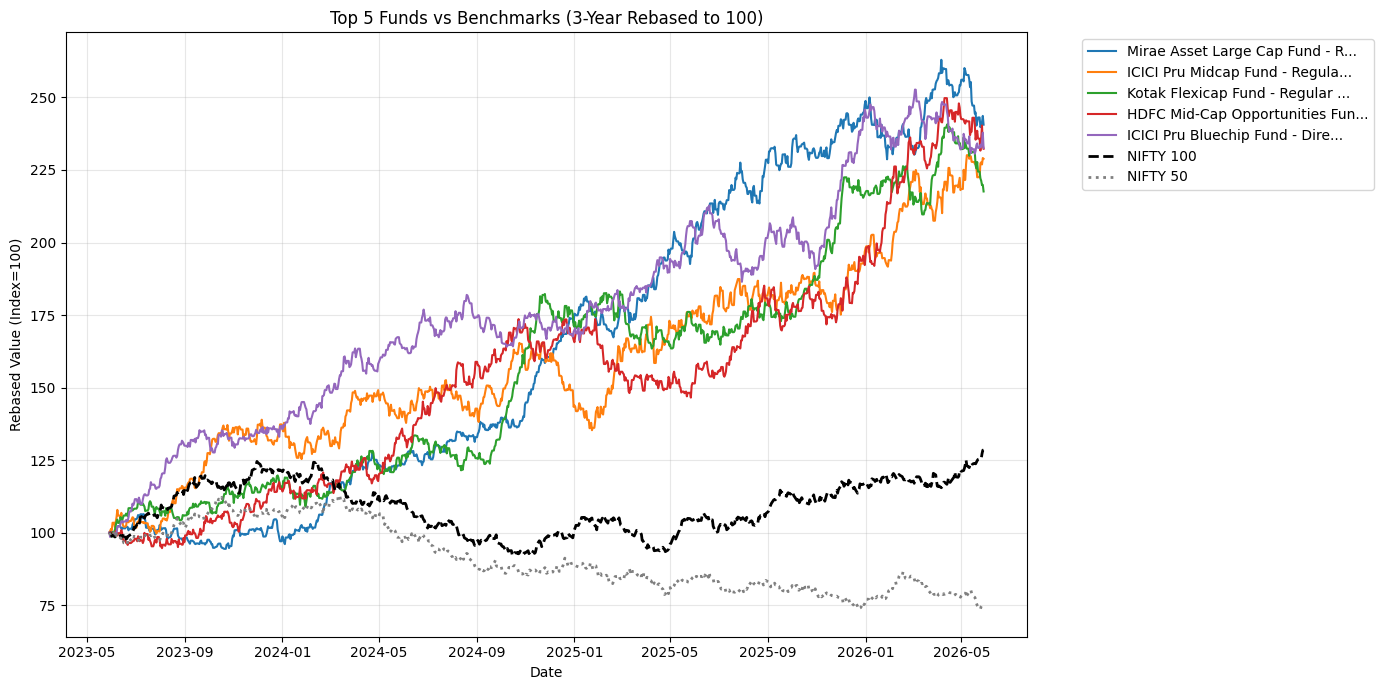

Tracking Errors (vs NIFTY 100):
                                                Fund  Tracking_Error
0      Mirae Asset Large Cap Fund - Regular - Growth        0.187867
1           ICICI Pru Midcap Fund - Regular - Growth        0.232515
2             Kotak Flexicap Fund - Regular - Growth        0.206410
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        0.224838
4          ICICI Pru Bluechip Fund - Direct - Growth        0.187312


In [8]:
# Get top 5 funds from scorecard
top_5_codes = df_score['amfi_code'].head(5).tolist()

# Get NIFTY50 as well
try:
    nifty50 = df_bench[df_bench['index_name'] == 'NIFTY50'].set_index('date')['close_value'].sort_index()
except Exception:
    nifty50 = None

start_date_3yr = pivot_nav.index.max() - pd.DateOffset(years=3)

plt.figure(figsize=(14, 7))

tracking_errors = []

for code in top_5_codes:
    fund_nav = pivot_nav[code][pivot_nav.index >= start_date_3yr].dropna()
    if fund_nav.empty: continue
    
    # Rebase to 100
    fund_rebased = (fund_nav / fund_nav.iloc[0]) * 100
    plt.plot(fund_rebased.index, fund_rebased.values, label=fund_dict[code][:30] + '...')
    
    # Tracking Error vs Nifty 100
    aligned = pd.concat([daily_returns[code], nifty100_ret], axis=1).dropna()
    aligned = aligned[aligned.index >= start_date_3yr]
    if not aligned.empty:
        te = (aligned.iloc[:,0] - aligned.iloc[:,1]).std() * np.sqrt(252)
        tracking_errors.append({'Fund': fund_dict[code], 'Tracking_Error': te})

# Plot Benchmarks
if not nifty100.empty:
    n100 = nifty100[nifty100.index >= start_date_3yr]
    if not n100.empty:
        n100_rebased = (n100 / n100.iloc[0]) * 100
        plt.plot(n100_rebased.index, n100_rebased.values, label='NIFTY 100', color='black', linewidth=2, linestyle='--')

if nifty50 is not None and not nifty50.empty:
    n50 = nifty50[nifty50.index >= start_date_3yr]
    if not n50.empty:
        n50_rebased = (n50 / n50.iloc[0]) * 100
        plt.plot(n50_rebased.index, n50_rebased.values, label='NIFTY 50', color='gray', linewidth=2, linestyle=':')

plt.title('Top 5 Funds vs Benchmarks (3-Year Rebased to 100)')
plt.xlabel('Date')
plt.ylabel('Rebased Value (Index=100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/benchmark_comparison.png')
plt.show()

# Display Tracking Errors
print("Tracking Errors (vs NIFTY 100):")
print(pd.DataFrame(tracking_errors))
